In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# TASK 1

#### Load the Dataset

In [36]:
df = pd.read_csv('task_excel.csv')

#### Display Dataset shape

In [37]:
print(df.shape)

(76000, 10)


#### Display First 5 rows

In [38]:
df.head(5)

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
0,1000000,2022-05-29,West,Mumbai,Python,Offline,144770.33,40.0,Ongoing,Not Placed
1,1000001,2022-01-29,NaN,Chennai,Web Development,Hybrid,174792.23,52.0,NaN,Not Placed
2,1000002,2021-01-22,South,Kolkata,Web Development,Online,92417.81,79.0,Completed,Placed
3,1000003,2022-12-15,North,Pune,Cyber Security,Online,105916.82,89.0,Dropped,Not Placed
4,1000004,2022-06-07,East,Hyderabad,Python,Offline,18927.99,68.0,Completed,Not Eligible


#### Display last 5 rows

In [39]:
df.tail(5)

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
75995,1065700,2020-09-08,East,Pune,Data Science,Online,168844.57,76.0,Dropped,Placed
75996,1024679,2021-02-22,North,Chennai,Web Development,Offline,71334.46,90.0,Ongoing,NaN
75997,1069831,2022-03-16,North,Delhi,Web Development,Online,143528.38,83.0,Dropped,Placed
75998,1068292,2022-06-17,North,Ahmedabad,Python,Online,195770.58,87.0,Completed,Not Eligible
75999,1040147,2023-07-12,West,Pune,NaN,Hybrid,36469.78,81.0,Completed,Not Placed


# Task 2

#### Check Missing Value

In [40]:
df.isnull().sum()


Student_ID                0
Enrollment_Date           0
Region                18612
City                   8570
Course_Name            7519
Learning_Mode             0
Fees_Paid                 0
Attendance_Percent     1244
Course_Status          7508
Placement_Status       7527
dtype: int64

#### Validate Datatype

In [42]:
df.dtypes

Student_ID              int64
Enrollment_Date        object
Region                 object
City                   object
Course_Name            object
Learning_Mode          object
Fees_Paid             float64
Attendance_Percent    float64
Course_Status          object
Placement_Status       object
dtype: object

#### Handle Duplicate Records

In [43]:
df.duplicated().sum()

np.int64(4000)

In [44]:
df.drop_duplicates(inplace=True)

In [52]:
df

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
0,1000000,2022-05-29,West,Mumbai,Python,Offline,144770.33,40.0,Ongoing,Not Placed
1,1000001,2022-01-29,NaN,Chennai,Web Development,Hybrid,174792.23,52.0,NaN,Not Placed
2,1000002,2021-01-22,South,Kolkata,Web Development,Online,92417.81,79.0,Completed,Placed
3,1000003,2022-12-15,North,Pune,Cyber Security,Online,105916.82,89.0,Dropped,Not Placed
4,1000004,2022-06-07,East,Hyderabad,Python,Offline,18927.99,68.0,Completed,Not Eligible
...,...,...,...,...,...,...,...,...,...,...
71995,1071995,2022-03-07,NaN,Chennai,Data Science,Offline,46250.83,86.0,Dropped,Not Placed
71996,1071996,2023-01-25,North,Kolkata,AI/ML,Offline,88703.65,64.0,Completed,Not Placed
71997,1071997,2022-08-05,West,NaN,NaN,Online,212770.78,40.0,Ongoing,Placed
71998,1071998,2022-10-22,West,Ahmedabad,AI/ML,Offline,80322.48,45.0,Ongoing,Not Placed


#### Summary Stastics

In [45]:
df.describe(include='all')

,Student_ID,Enrollment_Date,Region,City,Course_Name,Learning_Mode,Fees_Paid,Attendance_Percent,Course_Status,Placement_Status
count,7.200000e+04,72000,54346,63833,64845,72000,72000.000000,70817.000000,64870,64875
unique,NaN,1200,5,8,6,3,NaN,NaN,3,3
top,NaN,2023-03-18,Central,Hyderabad,Python,Online,NaN,NaN,Ongoing,Not Placed
freq,NaN,87,10972,8116,13028,32607,NaN,NaN,32681,28755
mean,1.036000e+06,NaN,NaN,NaN,NaN,NaN,127405.027434,70.040696,NaN,NaN
std,2.078475e+04,NaN,NaN,NaN,NaN,NaN,70797.576088,17.609462,NaN,NaN
min,1.000000e+06,NaN,NaN,NaN,NaN,NaN,5003.130000,40.000000,NaN,NaN
25%,1.018000e+06,NaN,NaN,NaN,NaN,NaN,66010.192500,55.000000,NaN,NaN
50%,1.036000e+06,NaN,NaN,NaN,NaN,NaN,127365.670000,70.000000,NaN,NaN
75%,1.053999e+06,NaN,NaN,NaN,NaN,NaN,188838.717500,85.000000,NaN,NaN


#### Course wise Distribution

In [46]:
df['Course_Name'].value_counts()

Course_Name
Python             13028
AI/ML              12986
Data Science       12817
Web Development    10870
Cyber Security     10838
Cloud Computing     4306
Name: count, dtype: int64

#### Region Wise Distribution

In [47]:
df['Region'].value_counts()

Region
Central    10972
North      10887
West       10859
South      10853
East       10775
Name: count, dtype: int64

# TASK 3

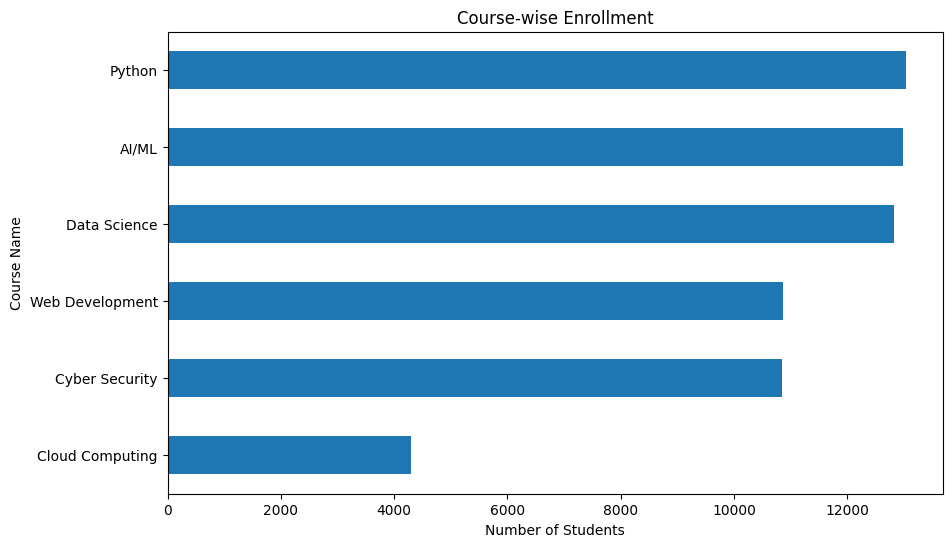

In [48]:
course_enrollment = df.groupby('Course_Name')['Student_ID'].count()
plt.figure(figsize=(10, 6))
course_enrollment.sort_values().plot(kind='barh')
plt.title('Course-wise Enrollment')
plt.xlabel('Number of Students')
plt.ylabel('Course Name')
plt.show()

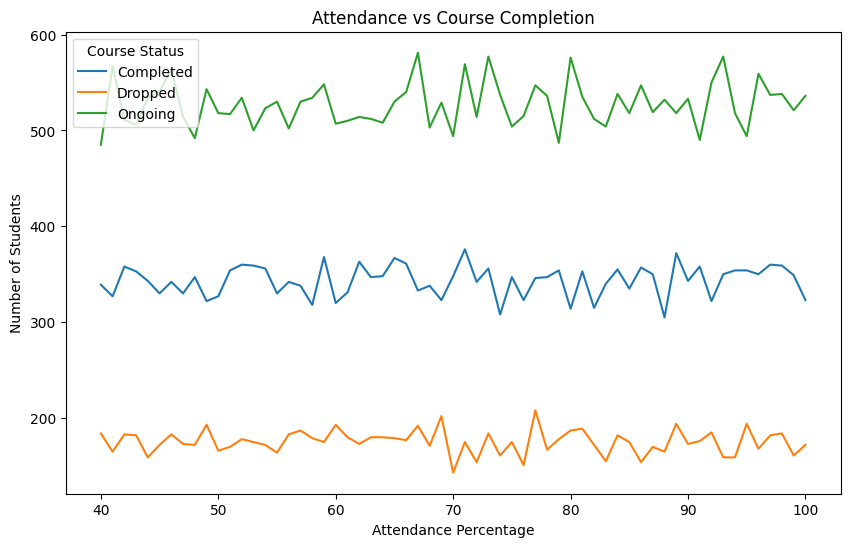

In [49]:
attendance_completion = df.groupby('Attendance_Percent')['Course_Status'].value_counts().unstack().fillna(0)
attendance_completion.plot(kind='line', figsize=(10, 6))
plt.title('Attendance vs Course Completion')
plt.xlabel('Attendance Percentage')
plt.ylabel('Number of Students')
plt.legend(title='Course Status')
plt.show()

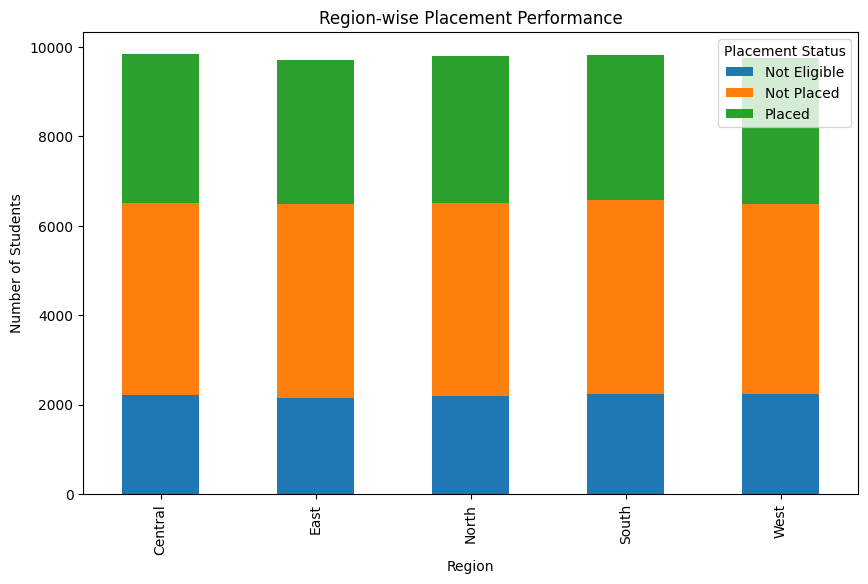

In [50]:
region_placement = df.groupby('Region')['Placement_Status'].value_counts().unstack().fillna(0)
region_placement.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Region-wise Placement Performance')
plt.xlabel('Region')
plt.ylabel('Number of Students')
plt.legend(title='Placement Status')
plt.show()

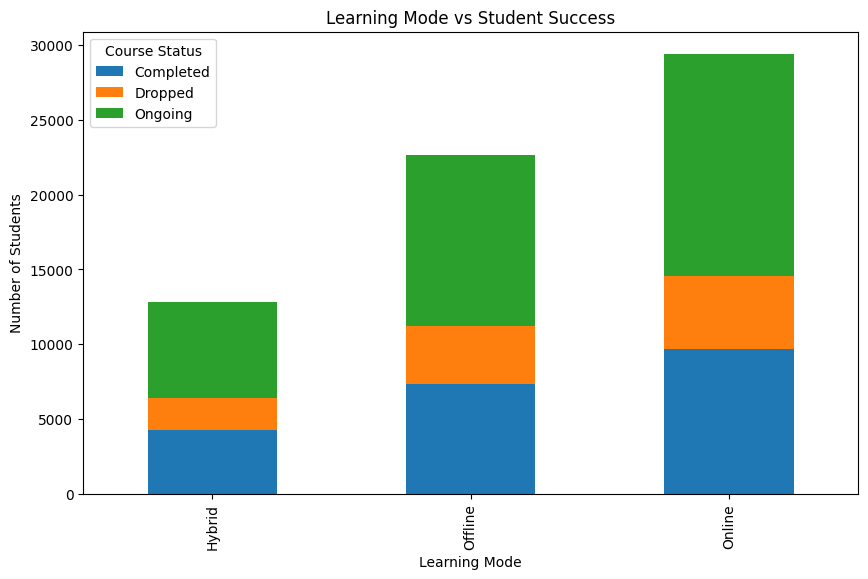

In [51]:
learning_mode_success = df.groupby('Learning_Mode')['Course_Status'].value_counts().unstack().fillna(0)
learning_mode_success.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Learning Mode vs Student Success')
plt.xlabel('Learning Mode')
plt.ylabel('Number of Students')
plt.legend(title='Course Status')
plt.show()

# TASK 4

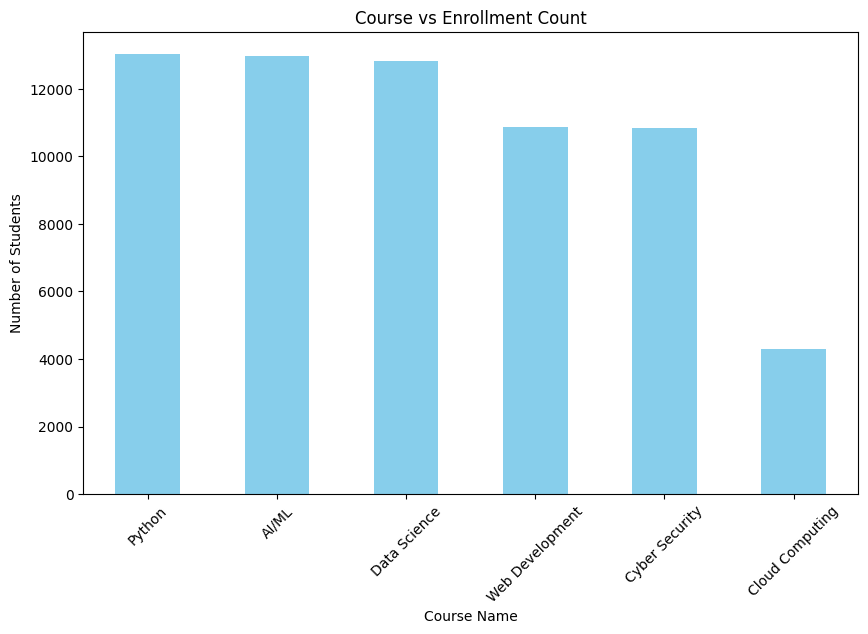

In [53]:
# Task 1: Bar chart (Course vs Enrollment Count)
plt.figure(figsize=(10, 6))
course_enrollment = df['Course_Name'].value_counts()
course_enrollment.plot(kind='bar', color='skyblue')
plt.title('Course vs Enrollment Count')
plt.xlabel('Course Name')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()

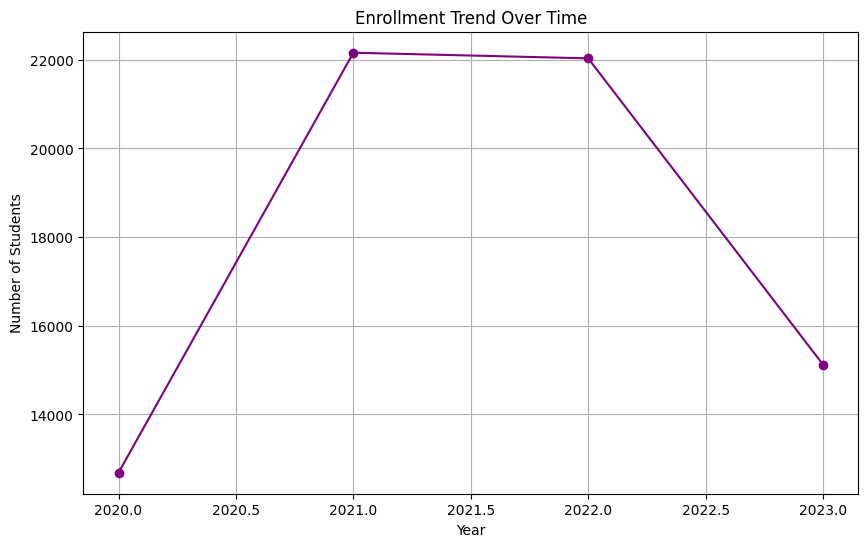

In [54]:

# Task 2: Line chart (Enrollment trend over time)
# First, extract the year or month from the 'Enrollment_Date' column
df['Enrollment_Date'] = pd.to_datetime(df['Enrollment_Date'])
df['Year'] = df['Enrollment_Date'].dt.year

# Group by Year and count the enrollments
enrollment_trend = df.groupby('Year')['Student_ID'].count()

plt.figure(figsize=(10, 6))
enrollment_trend.plot(kind='line', marker='o', color='purple')
plt.title('Enrollment Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.grid(True)
plt.show()

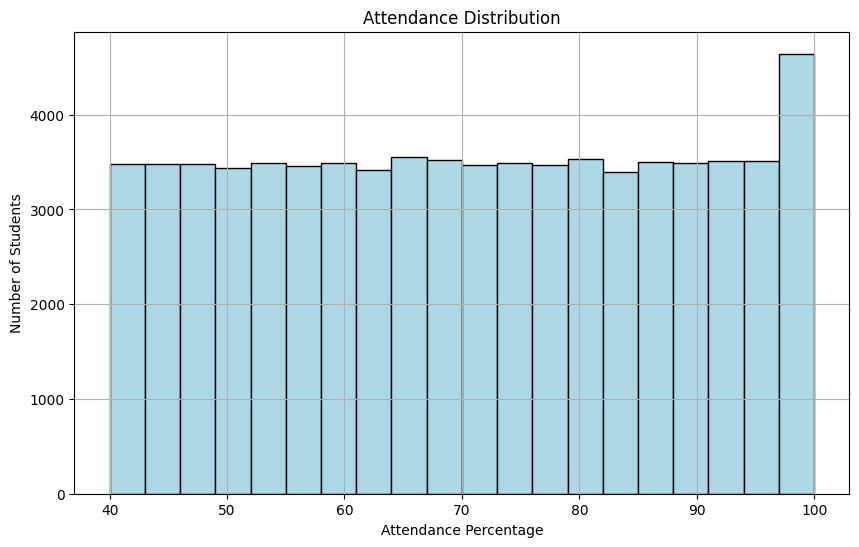

In [56]:

# Task 3: Histogram (Attendance distribution)
plt.figure(figsize=(10, 6))
df['Attendance_Percent'].plot(kind='hist', bins=20, color='lightblue', edgecolor='black')
plt.title('Attendance Distribution')
plt.xlabel('Attendance Percentage')
plt.ylabel('Number of Students')
plt.grid(True)
plt.show()

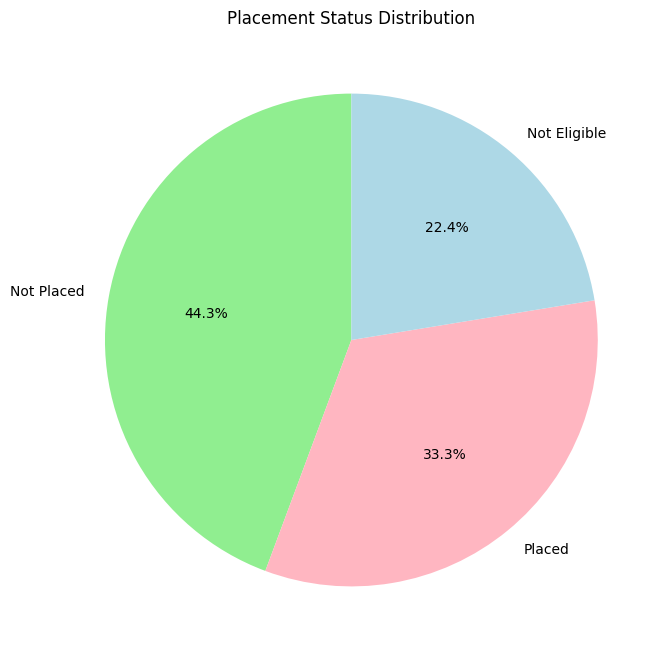

In [63]:
# Task 5: Pie Plot (Placement Status Distribution)
plt.figure(figsize=(8, 8))
placement_status_counts = df['Placement_Status'].value_counts()
placement_status_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'lightpink','lightblue'], startangle=90)
plt.title('Placement Status Distribution')
plt.ylabel('')  # Hide the y-axis label
plt.show()

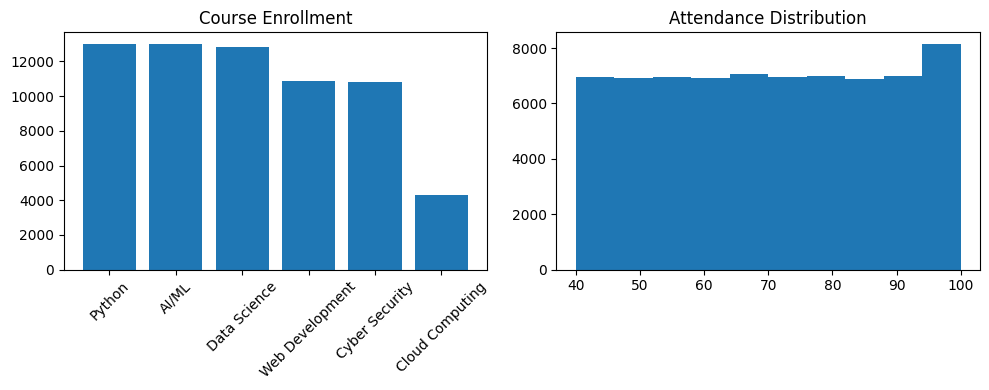

In [65]:
# Sub plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(course_enrollment.index, course_enrollment.values)
plt.title('Course Enrollment')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.hist(df['Attendance_Percent'], bins=10)
plt.title('Attendance Distribution')

plt.tight_layout()
plt.show() 

# TASK 5

In [66]:
key_findings = {
    "Top Courses": df['Course_Name'].value_counts().head(),
    "Best Region (Placements)": df[df['Placement_Status'] == 'Placed']['Region'].value_counts().head(),
    "Learning Mode Preference": df['Learning_Mode'].value_counts()
}

for k, v in key_findings.items():
    print(f"\n{k}:\n{v}")


Top Courses:
Course_Name
Python             13028
AI/ML              12986
Data Science       12817
Web Development    10870
Cyber Security     10838
Name: count, dtype: int64

Best Region (Placements):
Region
Central    3336
North      3275
West       3271
East       3231
South      3227
Name: count, dtype: int64

Learning Mode Preference:
Learning_Mode
Online     32607
Offline    25179
Hybrid     14214
Name: count, dtype: int64


In [67]:
education_insights = df.groupby('Course_Status')['Attendance_Percent'].mean()
print(education_insights)

print()

placement_insights = df['Placement_Status'].value_counts()
print(placement_insights)

Course_Status
Completed    70.067243
Dropped      69.896016
Ongoing      70.100100
Name: Attendance_Percent, dtype: float64

Placement_Status
Not Placed      28755
Placed          21574
Not Eligible    14546
Name: count, dtype: int64


In [68]:
improvement_metrics = df.groupby('Learning_Mode').agg({
    'Attendance_Percent': 'mean',
    'Fees_Paid': 'mean'
})

print(improvement_metrics)

               Attendance_Percent      Fees_Paid
Learning_Mode                                   
Hybrid                  69.840329  127798.741210
Offline                 70.223461  127692.833313
Online                  69.987066  127011.157655


In [ ]:
# Final Summary
 
final_summary = df.describe()
print(final_summary)

         Student_ID             Enrollment_Date      Fees_Paid  \
count  7.200000e+04                       72000   72000.000000   
mean   1.036000e+06  2022-01-20 12:26:34.800000  127405.027434   
min    1.000000e+06         2020-06-01 00:00:00    5003.130000   
25%    1.018000e+06         2021-03-30 00:00:00   66010.192500   
50%    1.036000e+06         2022-01-19 00:00:00  127365.670000   
75%    1.053999e+06         2022-11-13 00:00:00  188838.717500   
max    1.071999e+06         2023-09-13 00:00:00  249992.720000   
std    2.078475e+04                         NaN   70797.576088   

       Attendance_Percent          Year  
count        70817.000000  72000.000000  
mean            70.040696   2021.549931  
min             40.000000   2020.000000  
25%             55.000000   2021.000000  
50%             70.000000   2022.000000  
75%             85.000000   2022.000000  
max            100.000000   2023.000000  
std             17.609462      1.009920  
